In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms
import csv

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
print("device:", device)

device: cuda


In [2]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # mean/std для 1 канала
])


train_full = torchvision.datasets.EMNIST(
    root="./data", train=True, download=True, transform=transform, split="balanced"
)
test_ds = torchvision.datasets.EMNIST(
    root="./data", train=False, download=True, transform=transform, split="balanced"
)

class_names = train_full.classes
print("classes:", len(class_names))
print("train size:", len(train_full))
print("test size:", len(test_ds))

classes: 47
train size: 112800
test size: 18800


In [3]:
BATCH_SIZE = 256 if device.type == "cuda" else 64
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([256, 1, 28, 28]) torch.float32
y_batch: torch.Size([256]) torch.int64


In [4]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# sanity-check по форме
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)



def unpack_batch(batch):
    x, y = batch
    return x, y

batch = next(iter(train_loader))
x, y = unpack_batch(batch)

print("x:", type(x), x.shape, x.dtype)
print("y:", type(y), y.shape, y.dtype)

# Приведем x к виду (batch, input_dim) – нам нужен MLP
if x.dim() > 2:
    x_flat = x.view(x.size(0), -1)
else:
    x_flat = x

print("x_flat:", x_flat.shape)
     

     


logits: torch.Size([256, 47])
x: <class 'torch.Tensor'> torch.Size([256, 1, 28, 28]) torch.float32
y: <class 'torch.Tensor'> torch.Size([256]) torch.int64
x_flat: torch.Size([256, 784])


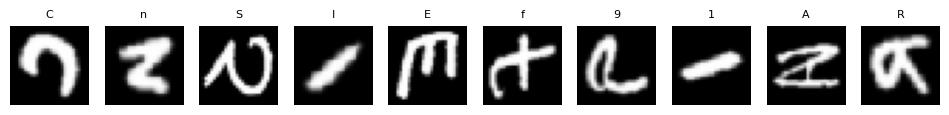

In [5]:
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [22]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for batch in loader:
        x, y = unpack_batch(batch)
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float('nan'), float('nan')

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for batch in loader:
        x, y = unpack_batch(batch)
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float('nan'), float('nan')

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen


def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history


def plot_history(hist, title="", save=False):
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    if save:
        plt.savefig("artifacts/figures/curves_best.png")
    plt.show()

    
def save_results(experiment_id, model_summary, optimizer, lr, momentum, weight_decay, epochs_trained, history, dataset="EMNIST", seed=42, file="artifacts/runs.csv"):
    best_val_accuracy = max(history["val_acc"])
    best_val_loss = min(history["val_loss"])

    fieldnames = [
        "experiment_id", "dataset", "seed", "model_summary", "optimizer", "lr", "momentum",
        "weight_decay", "epochs_trained", "best_val_accuracy", "best_val_loss",
    ]

    row = {
        "experiment_id": experiment_id,
        "dataset": dataset,
        "seed": seed,
        "model_summary": model_summary,
        "optimizer": optimizer,
        "lr": lr,
        "momentum": momentum,
        "weight_decay": weight_decay,
        "epochs_trained": epochs_trained,
        "best_val_accuracy": best_val_accuracy,
        "best_val_loss": best_val_loss,
    }

    file_exists = os.path.isfile(file)

    with open(file, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)

        if not file_exists:
            writer.writeheader()
        
        writer.writerow(row)

epoch 01/20 | train loss=1.4201, acc=0.6033 | val loss=0.9689, acc=0.7122
epoch 02/20 | train loss=0.8017, acc=0.7561 | val loss=0.7304, acc=0.7743
epoch 03/20 | train loss=0.6398, acc=0.7974 | val loss=0.6163, acc=0.8120
epoch 04/20 | train loss=0.5631, acc=0.8168 | val loss=0.5744, acc=0.8168
epoch 05/20 | train loss=0.5150, acc=0.8294 | val loss=0.5416, acc=0.8265
epoch 06/20 | train loss=0.4810, acc=0.8379 | val loss=0.5508, acc=0.8232
epoch 07/20 | train loss=0.4534, acc=0.8445 | val loss=0.5306, acc=0.8281
epoch 08/20 | train loss=0.4332, acc=0.8507 | val loss=0.5097, acc=0.8347
epoch 09/20 | train loss=0.4132, acc=0.8543 | val loss=0.4931, acc=0.8385
epoch 10/20 | train loss=0.3953, acc=0.8613 | val loss=0.5072, acc=0.8355
epoch 11/20 | train loss=0.3799, acc=0.8652 | val loss=0.4910, acc=0.8431
epoch 12/20 | train loss=0.3683, acc=0.8688 | val loss=0.5071, acc=0.8355
epoch 13/20 | train loss=0.3561, acc=0.8709 | val loss=0.5061, acc=0.8337
epoch 14/20 | train loss=0.3452, acc=0

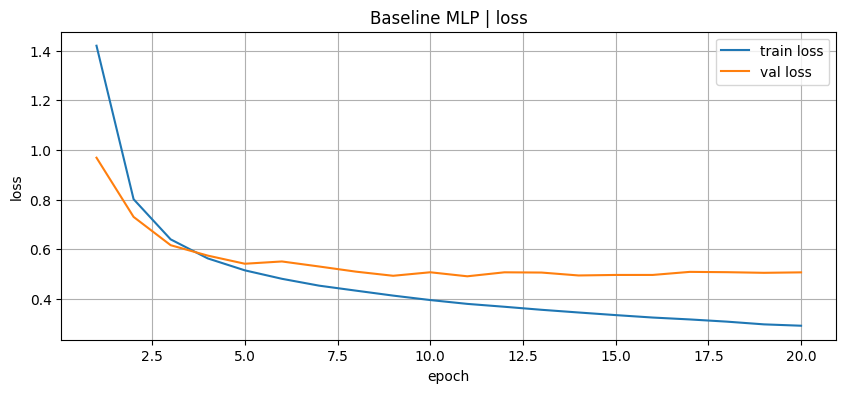

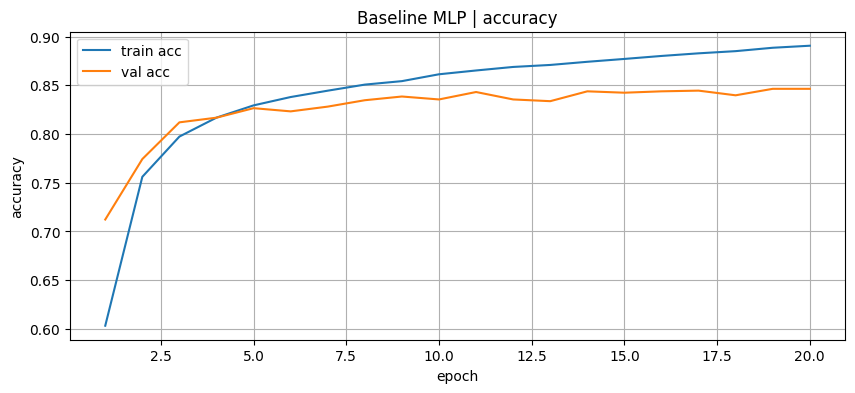

In [ ]:
# E1 (baseline)
seed = 42
lr = 1e-3
epochs = 20

set_seed(seed)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=lr)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion,
    epochs=epochs,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")
save_results(experiment_id="E1",
             model_summary="baseline",
             optimizer="Adam",
             lr=lr,
             momentum=0,
             weight_decay=0,
             epochs_trained=epochs,
             history=history_baseline,
             seed=seed
             )

epoch 01/20 | train loss=1.7663, acc=0.4991 | val loss=0.9726, acc=0.7089
epoch 02/20 | train loss=1.0989, acc=0.6672 | val loss=0.7726, acc=0.7670
epoch 03/20 | train loss=0.9466, acc=0.7073 | val loss=0.6830, acc=0.7897
epoch 04/20 | train loss=0.8694, acc=0.7290 | val loss=0.6559, acc=0.7934
epoch 05/20 | train loss=0.8219, acc=0.7413 | val loss=0.6001, acc=0.8064
epoch 06/20 | train loss=0.7893, acc=0.7489 | val loss=0.5855, acc=0.8094
epoch 07/20 | train loss=0.7692, acc=0.7541 | val loss=0.5629, acc=0.8201
epoch 08/20 | train loss=0.7458, acc=0.7601 | val loss=0.5538, acc=0.8225
epoch 09/20 | train loss=0.7297, acc=0.7635 | val loss=0.5407, acc=0.8273
epoch 10/20 | train loss=0.7137, acc=0.7688 | val loss=0.5353, acc=0.8262
epoch 11/20 | train loss=0.7013, acc=0.7708 | val loss=0.5318, acc=0.8271
epoch 12/20 | train loss=0.6959, acc=0.7731 | val loss=0.5150, acc=0.8323
epoch 13/20 | train loss=0.6816, acc=0.7768 | val loss=0.5172, acc=0.8339
epoch 14/20 | train loss=0.6774, acc=0

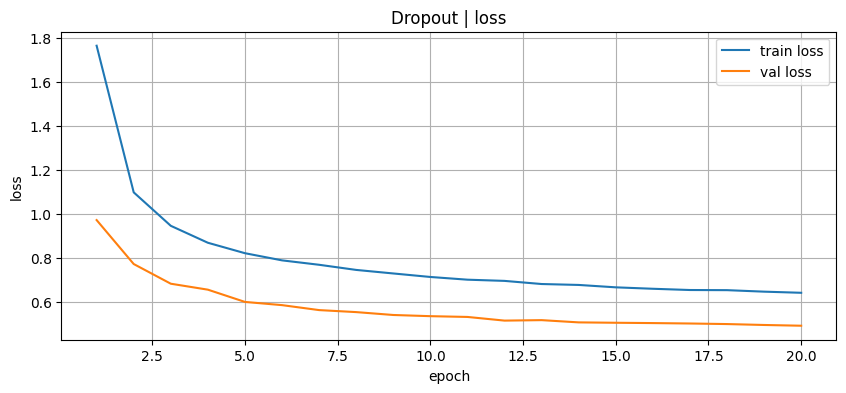

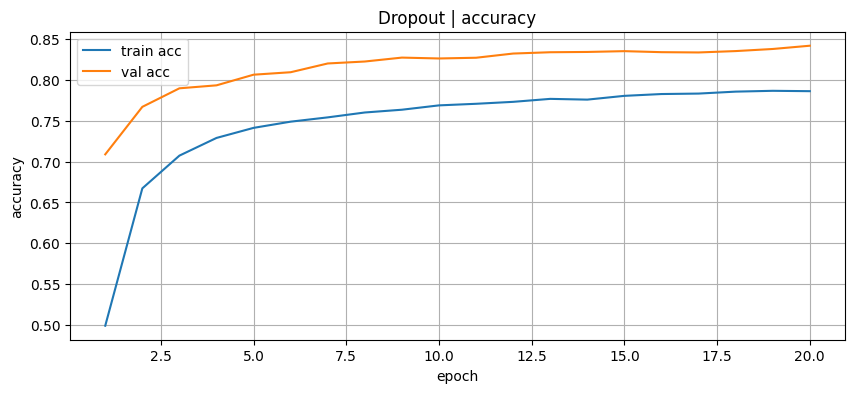

In [ ]:
# E2 (dropout)
seed = 42
lr = 1e-3
epochs = 20

set_seed(seed)
dropout = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout.parameters(), lr=lr)

history_dropout = fit(
    dropout, train_loader, val_loader,
    optimizer, criterion,
    epochs=epochs,
    early_stopping=None
)

plot_history(history_dropout, title="Dropout")
save_results(experiment_id="E2",
             model_summary="dropout",
             optimizer="Adam",
             lr=lr,
             momentum=0,
             weight_decay=0,
             epochs_trained=epochs,
             history=history_dropout,
             seed=seed
             )

epoch 01/20 | train loss=1.0896, acc=0.7206 | val loss=0.6364, acc=0.8017
epoch 02/20 | train loss=0.5321, acc=0.8276 | val loss=0.5331, acc=0.8252
epoch 03/20 | train loss=0.4435, acc=0.8497 | val loss=0.4856, acc=0.8401
epoch 04/20 | train loss=0.3935, acc=0.8644 | val loss=0.4606, acc=0.8480
epoch 05/20 | train loss=0.3619, acc=0.8717 | val loss=0.4780, acc=0.8399
epoch 06/20 | train loss=0.3344, acc=0.8807 | val loss=0.4603, acc=0.8465
epoch 07/20 | train loss=0.3135, acc=0.8861 | val loss=0.4641, acc=0.8465
epoch 08/20 | train loss=0.2966, acc=0.8902 | val loss=0.4555, acc=0.8467
epoch 09/20 | train loss=0.2785, acc=0.8961 | val loss=0.4600, acc=0.8495
epoch 10/20 | train loss=0.2687, acc=0.8976 | val loss=0.4608, acc=0.8516
epoch 11/20 | train loss=0.2536, acc=0.9033 | val loss=0.4769, acc=0.8479
epoch 12/20 | train loss=0.2428, acc=0.9066 | val loss=0.4859, acc=0.8463
epoch 13/20 | train loss=0.2313, acc=0.9098 | val loss=0.5035, acc=0.8419
epoch 14/20 | train loss=0.2221, acc=0

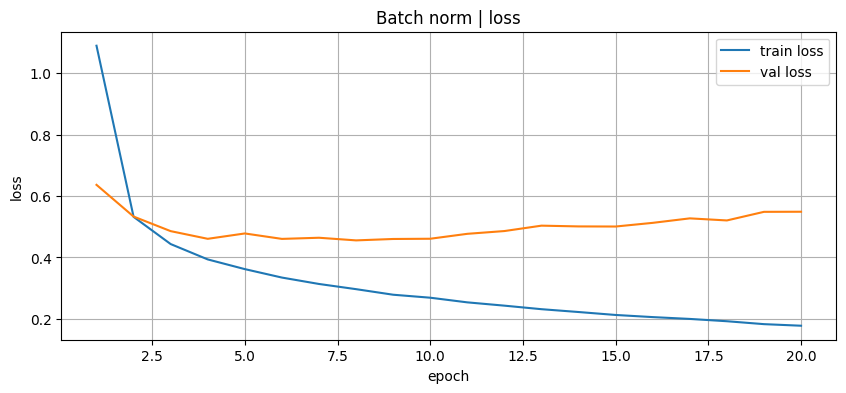

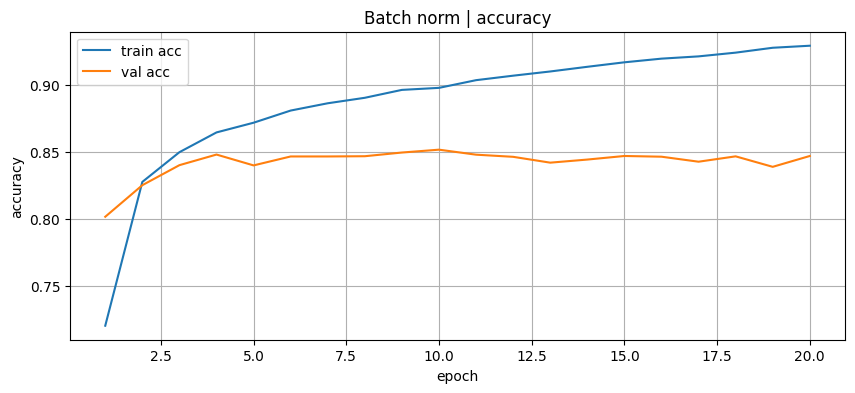

In [ ]:
# E3 (BatchNorm)
seed = 42
lr = 1e-3
epochs = 20

set_seed(seed)
batch_norm = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(batch_norm.parameters(), lr=lr)

history_batch_norm = fit(
    batch_norm, train_loader, val_loader,
    optimizer, criterion,
    epochs=epochs,
    early_stopping=None
)

plot_history(history_batch_norm, title="Batch norm")
save_results(experiment_id="E3",
             model_summary="batchnorm",
             optimizer="Adam",
             lr=lr,
             momentum=0,
             weight_decay=0,
             epochs_trained=epochs,
             history=history_batch_norm,
             seed=seed
             )

Самый лучший accuracy на validation у модели с Batch norm, поэтому для E4 используем batch norm и Early stopping

In [12]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

epoch 01/20 | train loss=1.0896, acc=0.7206 | val loss=0.6364, acc=0.8017
epoch 02/20 | train loss=0.5321, acc=0.8276 | val loss=0.5331, acc=0.8252
epoch 03/20 | train loss=0.4435, acc=0.8497 | val loss=0.4856, acc=0.8401
epoch 04/20 | train loss=0.3935, acc=0.8644 | val loss=0.4606, acc=0.8480
epoch 05/20 | train loss=0.3619, acc=0.8717 | val loss=0.4780, acc=0.8399
epoch 06/20 | train loss=0.3344, acc=0.8807 | val loss=0.4603, acc=0.8465
epoch 07/20 | train loss=0.3135, acc=0.8861 | val loss=0.4641, acc=0.8465
epoch 08/20 | train loss=0.2966, acc=0.8902 | val loss=0.4555, acc=0.8467
EarlyStopping: остановка на эпохе 8. Лучший val_acc=0.8480


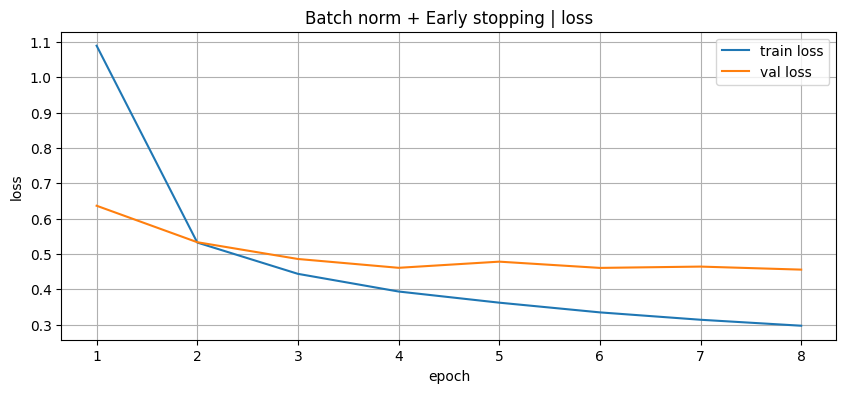

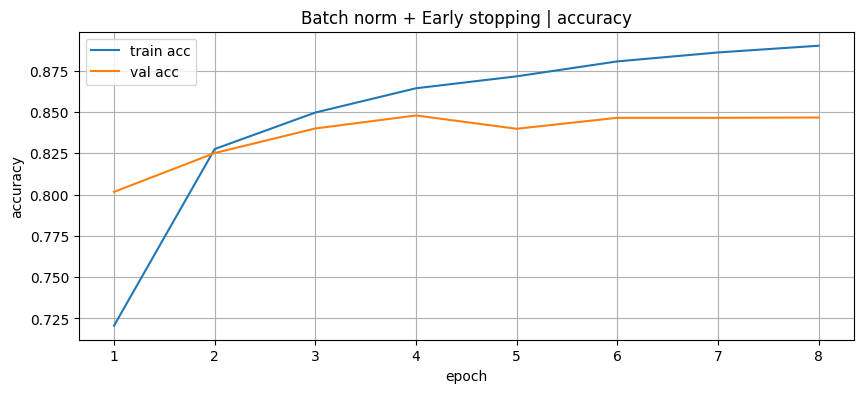

In [ ]:
# E4 (BatchNorm + Early stopping)
seed = 42
lr = 1e-3
epochs = 20

set_seed(seed)
batch_norm_stopping = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(batch_norm_stopping.parameters(), lr=lr)

history_batch_norm_stopping = fit(
    batch_norm_stopping, train_loader, val_loader,
    optimizer, criterion,
    epochs=epochs,
    early_stopping=EarlyStopping(patience=4)
)

epochs_trained = len(history_batch_norm_stopping["val_acc"])

plot_history(history_batch_norm_stopping, title="Batch norm + Early stopping", save=True)
save_results(experiment_id="E4",
             model_summary="batchnorm + earlystopping",
             optimizer="Adam",
             lr=lr,
             momentum=0,
             weight_decay=0,
             epochs_trained=epochs_trained,
             history=history_batch_norm_stopping,
             seed=seed
             )

In [38]:
import json

torch.save(batch_norm_stopping.state_dict(), "artifacts/best_model.pt")

best_config = {
    "seed": seed,
    "dataset": "EMNIST",
    "mode_summary": "batchnorm + earlystopping",
    "hidden_dims": (256, 128),
    "optimizer": "Adam",
    "lr": lr,
    "dropout_p": 0.0,
    "batchnorm": True,
    "momentum": 0,
    "weight_decay": 0,
    "patience": 4,
    "epochs_trained": epochs_trained
}

with open("artifacts/best_config.json", 'w', encoding="utf-8") as f:
    json.dump(best_config, f, indent=4)


best_test_loss, best_test_acc = evaluate(batch_norm_stopping, test_loader, nn.CrossEntropyLoss())
print("Точность на test для лучшей модели: ", best_test_acc)

Точность на test для лучшей модели:  0.841436170212766


epoch 01/6 | train loss=7.4892, acc=0.0221 | val loss=3.8604, acc=0.0204
epoch 02/6 | train loss=3.8592, acc=0.0208 | val loss=3.8573, acc=0.0203
epoch 03/6 | train loss=3.8601, acc=0.0205 | val loss=3.8579, acc=0.0206
epoch 04/6 | train loss=3.8589, acc=0.0206 | val loss=3.8574, acc=0.0228
epoch 05/6 | train loss=3.8598, acc=0.0206 | val loss=3.8620, acc=0.0216
epoch 06/6 | train loss=3.8599, acc=0.0208 | val loss=3.8634, acc=0.0221


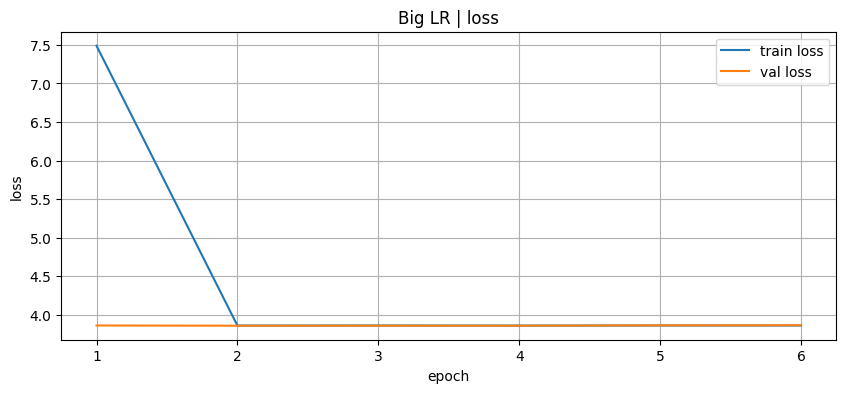

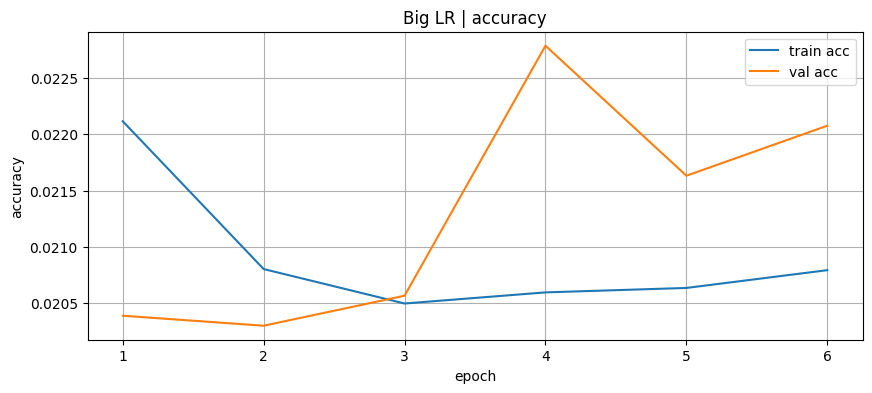

In [25]:
# O1 (LR слишком большой)
seed = 42
lr = 1e-1
epochs = 6

set_seed(seed)
big_lr = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(big_lr.parameters(), lr=lr)

history_big_lr = fit(
    big_lr, train_loader, val_loader,
    optimizer, criterion,
    epochs=epochs,
    early_stopping=None
)

plot_history(history_big_lr, title="Big LR")
save_results(experiment_id="O1",
             model_summary="big lr",
             optimizer="Adam",
             lr=lr,
             momentum=0,
             weight_decay=0,
             epochs_trained=epochs,
             history=history_big_lr,
             seed=seed
             )

epoch 01/8 | train loss=3.7650, acc=0.0913 | val loss=3.6394, acc=0.1659
epoch 02/8 | train loss=3.4489, acc=0.2354 | val loss=3.2415, acc=0.2936
epoch 03/8 | train loss=3.0201, acc=0.3443 | val loss=2.8040, acc=0.3878
epoch 04/8 | train loss=2.6172, acc=0.4249 | val loss=2.4452, acc=0.4537
epoch 05/8 | train loss=2.3063, acc=0.4747 | val loss=2.1807, acc=0.4941
epoch 06/8 | train loss=2.0781, acc=0.5058 | val loss=1.9881, acc=0.5189
epoch 07/8 | train loss=1.9115, acc=0.5276 | val loss=1.8466, acc=0.5398
epoch 08/8 | train loss=1.7881, acc=0.5451 | val loss=1.7415, acc=0.5565


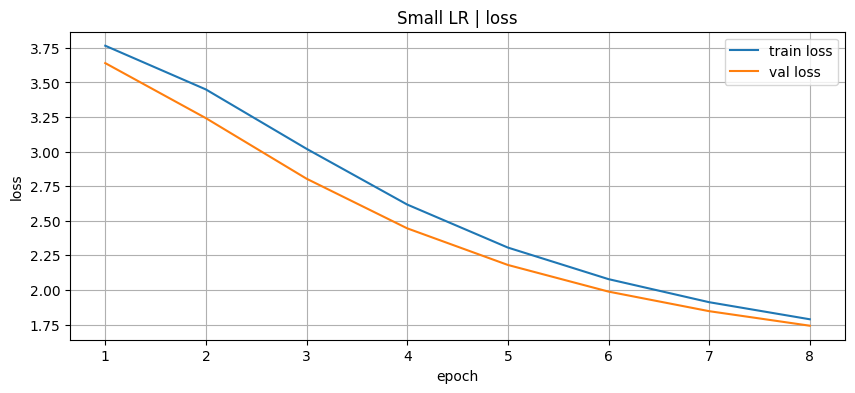

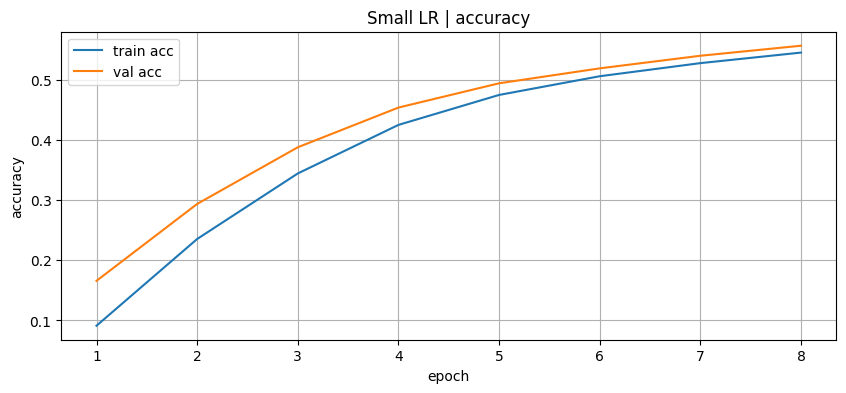

In [26]:
# O2 (LR слишком маленький)
seed = 42
lr = 1e-5
epochs = 8

set_seed(seed)
small_lr = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(small_lr.parameters(), lr=lr)

history_small_lr = fit(
    small_lr, train_loader, val_loader,
    optimizer, criterion,
    epochs=epochs,
    early_stopping=None
)

plot_history(history_small_lr, title="Small LR")
save_results(experiment_id="O2",
             model_summary="small lr",
             optimizer="Adam",
             lr=lr,
             momentum=0,
             weight_decay=0,
             epochs_trained=epochs,
             history=history_small_lr,
             seed=seed
             )

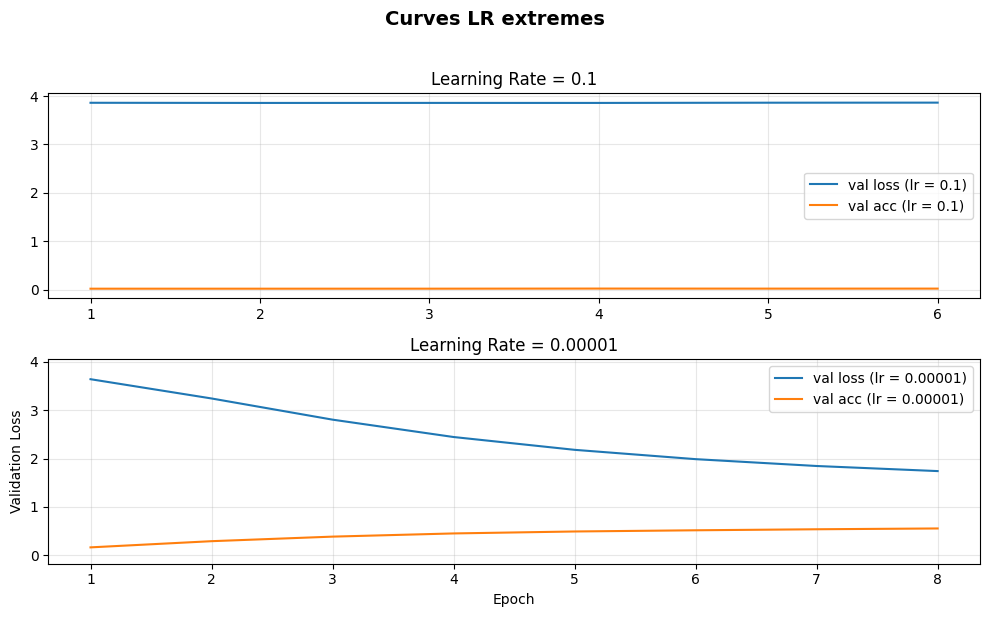

In [35]:
def plot_lr_extremes(hist_big, hist_small, title="Curves LR extremes", save=False):
    epochs_big = list(range(1, len(hist_big["val_loss"]) + 1))
    epochs_small = list(range(1, len(hist_small["val_loss"]) + 1))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=False, sharey=True)
    
    ax1.plot(epochs_big, hist_big["val_loss"], 
             label="val loss (lr = 0.1)")
    ax1.plot(epochs_big, hist_big["val_acc"], 
            label="val acc (lr = 0.1)")
    ax2.set_xlabel("Epoch")
    ax1.set_title("Learning Rate = 0.1")
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='best')
    ax1.set_xticks(epochs_big)
    
    ax2.plot(epochs_small, hist_small["val_loss"], 
             label="val loss (lr = 0.00001)")
    ax2.plot(epochs_small, hist_small["val_acc"], 
            label="val acc (lr = 0.00001)")
    ax2.set_ylabel("Validation Loss")
    ax2.set_title("Learning Rate = 0.00001")
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='best')
    ax2.set_xticks(epochs_small)
    
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    
    if save:
        plt.savefig("artifacts/figures/curves_lr_extremes.png", dpi=300, bbox_inches='tight')
    
    plt.show()

plot_lr_extremes(history_big_lr, history_small_lr, save=True)

epoch 01/12 | train loss=3.7575, acc=0.0928 | val loss=3.5895, acc=0.1712
epoch 02/12 | train loss=3.1601, acc=0.2829 | val loss=2.6298, acc=0.3968
epoch 03/12 | train loss=2.1968, acc=0.4639 | val loss=1.8689, acc=0.5175
epoch 04/12 | train loss=1.6981, acc=0.5441 | val loss=1.5771, acc=0.5681
epoch 05/12 | train loss=1.4962, acc=0.5841 | val loss=1.4467, acc=0.5958
epoch 06/12 | train loss=1.3922, acc=0.6083 | val loss=1.3714, acc=0.6145
epoch 07/12 | train loss=1.3277, acc=0.6248 | val loss=1.3219, acc=0.6245
epoch 08/12 | train loss=1.2807, acc=0.6379 | val loss=1.2792, acc=0.6415
epoch 09/12 | train loss=1.2431, acc=0.6477 | val loss=1.2446, acc=0.6504
epoch 10/12 | train loss=1.2113, acc=0.6570 | val loss=1.2121, acc=0.6553
epoch 11/12 | train loss=1.1830, acc=0.6646 | val loss=1.1907, acc=0.6625
epoch 12/12 | train loss=1.1570, acc=0.6718 | val loss=1.1602, acc=0.6738


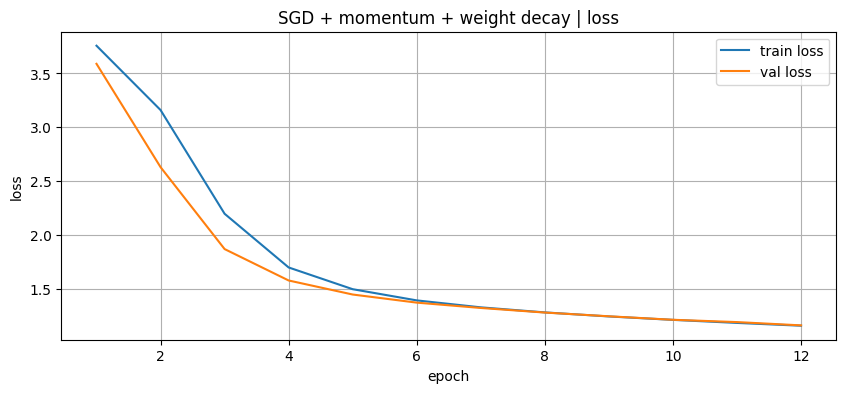

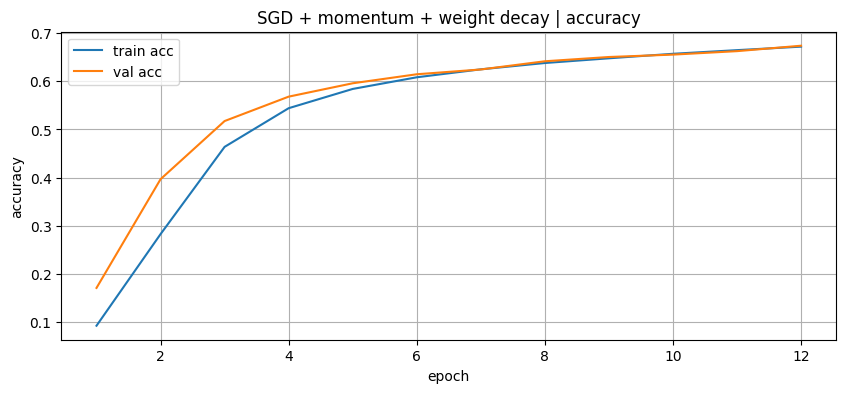

In [36]:
# O3 (SGD + momentum + weight decay)
seed = 42
lr = 1e-3
momentum = 0.9
weight_decay = 1e-4
epochs = 12

set_seed(seed)
sgd_momentum = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(sgd_momentum.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

history_sgd_momentum = fit(
    sgd_momentum, train_loader, val_loader,
    optimizer, criterion,
    epochs=epochs,
    early_stopping=None
)

plot_history(history_sgd_momentum, title="SGD + momentum + weight decay")
save_results(experiment_id="O3",
             model_summary="SGD + momentum + weight_decay",
             optimizer="SGD",
             lr=lr,
             momentum=momentum,
             weight_decay=weight_decay,
             epochs_trained=epochs,
             history=history_sgd_momentum,
             seed=seed
             )